# Notebook 01 — Source Exploration

I started with a map of the London Tube that showed life expectancy at each station ([*Lives on the Line*, by James Cheshire and Oliver O’Brien](https://jcheshire.com/featured-maps/lives-on-the-line/)). Places a few stops apart had very different health outcomes, and a railway map made that easy to see. I wanted to know if Birmingham’s rail corridors would do the same. The more I looked, the more I cared about neighbouring areas that differ a lot, railway or not. So I’m going city-wide instead of line by line.

## Why healthy life expectancy

Life expectancy tells you how long people are expected to live. **Healthy life expectancy (HLE) tells you how many of those years are expected to be in good health.** Two areas can have a similar life expectancy and very different HLE. That gap is what I want to look at, and then I want to see how it lines up with things like income, housing, work, education and pollution. I’m not assuming any of those explain it.

HLE is my main dataset. Everything else gets compared against it later.

## Who it’s for

People who know Birmingham and the places around it, both the public and professionals. They should recognise the areas by name, read the maps, and relate what they see to what they already know. The numbers describe areas. They don’t tell you the future health of any one person who lives there.

## What this notebook does

I check the national HLE profile first. I use YData Profiling for that and I love it: it’s quick, and it catches problems early. Then I look hard at my 660 local areas: how they compare with the rest of the country, the gap between men and women, how precise the estimates are, which ones were imputed, and how much neighbouring areas differ. It finishes with what I’m taking into [Notebook 02 — Data Preparation](../B%20%E2%80%94%20Data%20Preparation/02_Data_Preparation.ipynb).

HLE source and definitions: [ONS MSOA health-state life expectancy, 2019–2023](https://www.ons.gov.uk/peoplepopulationandcommunity/healthandsocialcare/healthandlifeexpectancies/bulletins/healthstatelifeexpectancyestimatesformiddlelayersuperoutputareasenglandandwales/2019to2023).

## 1. Open the HLE source

I read the HLE workbook with pandas, and the MSOA boundary file to see which areas I’ve got. I don’t change either source file. The boundary file covers 660 MSOAs. That’s what I have to work with for now, not my final study area.

In [1]:
import sys
import pandas as pd
import geopandas as gpd
import re
import html
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
from pathlib import Path
from IPython.display import display

# Find the project from the notebook's current folder.
working_folder = Path.cwd()
project_folder = next(
    folder for folder in [working_folder, *working_folder.parents]
    if (folder / "Data/Raw").is_dir() or (folder / "data/raw").is_dir()
)
data_folder = project_folder / ("Data" if (project_folder / "Data").is_dir() else "data")

def project_data(relative_path):
    """Locate a data file or folder in either project layout."""
    parts = Path(relative_path).parts
    if data_folder.name == "data":
        parts = (parts[0].lower(), *parts[1:])
    return data_folder.joinpath(*parts)

def raw_file(filename):
    """Find an untouched source in the project's raw collection."""
    candidates = sorted(project_data("Raw").rglob(filename))
    if not candidates:
        # The working collection also contains the original Unit 2 downloads.
        candidates = sorted((project_folder.parent.parent / "Datasets/Raw").rglob(filename))
    if not candidates:
        raise FileNotFoundError(f"Raw source not found: {filename}")
    return candidates[0]


boundaries = gpd.read_file(raw_file("ons_msoa21_boundaries_exploratory_west_midlands.geojson"))
# Identify the published MSOA code field from its values.
boundary_code_field = next(
    field for field in boundaries.columns if field != "geometry"
    and boundaries[field].astype(str).str.fullmatch(r"[EW]020\d{5}").all()
)
coverage_codes = set(boundaries[boundary_code_field])
assert boundaries[boundary_code_field].is_unique
print(f"Available coverage: {len(coverage_codes):,} MSOAs")

Python version: 3.14.7
Available coverage: 660 MSOAs


## 2. The national profile

Before I zoom in, I ran a YData profile on the whole national file to catch any problems. The charts below come from that report. They show the national file with men and women mixed together, not just my areas. The full interactive report is linked under the summary table.

In [2]:
from IPython.display import Image, Markdown
from urllib.parse import quote
import os

profile_folder = project_folder / "Project Notes/01 EDA and Exploration/YData Profiles"
if not profile_folder.is_dir():
    profile_folder = project_folder / "reports/ydata"
hle_report = profile_folder / "hle---msoa-rows.html"
assert hle_report.is_file()
report_text = html.unescape(re.sub(r"<[^>]+>", " ", hle_report.read_text()))
report_text = re.sub(r"\s+", " ", report_text)
match = re.search(r"Number of variables\s+(\d+)\s+Number of observations\s+([\d,]+)\s+Missing cells\s+([\d,]+)", report_text)
assert match
profile_summary = pd.DataFrame({
    "HLE profile": ["Fields", "Observations", "Missing cells"],
    "Recorded value": [int(value.replace(",", "")) for value in match.groups()],
})
display(profile_summary)
display(Markdown(f"[Open the complete interactive HLE report]({quote(os.path.relpath(hle_report, Path.cwd()))})"))
profile_assets = Path.cwd() / "Assets/HLE YData"
assert profile_assets.is_dir(), "The supplied HLE chart assets belong beside this notebook"

def show_hle_profile_chart(filename):
    display(Image(filename=str(profile_assets / filename), width=1000))

,HLE profile,Recorded value
0,Fields,13
1,Observations,14527
2,Missing cells,0


[Open the complete interactive HLE report](../../reports/ydata/hle---msoa-rows.html)

The file has 13 fields and 14,527 rows, and no missing cells. The period and area type never change, which is what I expected. The imputation flags are nearly all zero because only a few estimates needed any filling in. A zero in those columns is a real answer, not a gap.

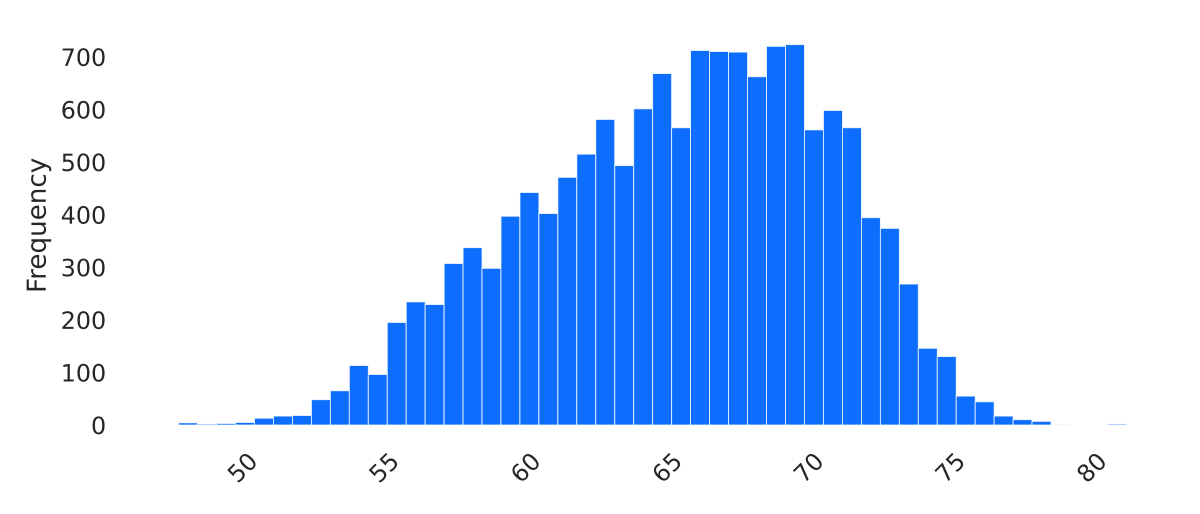

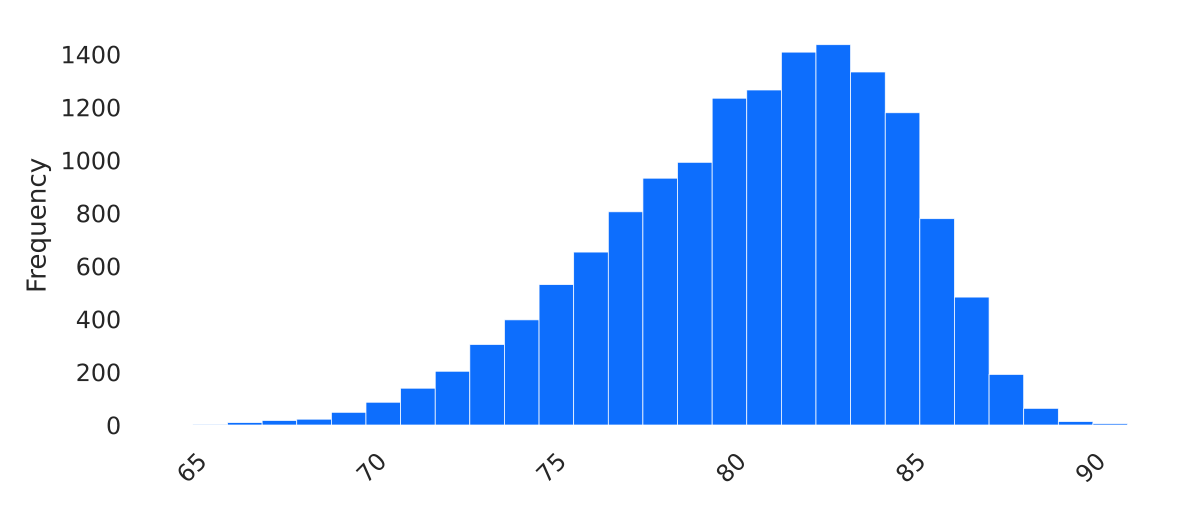

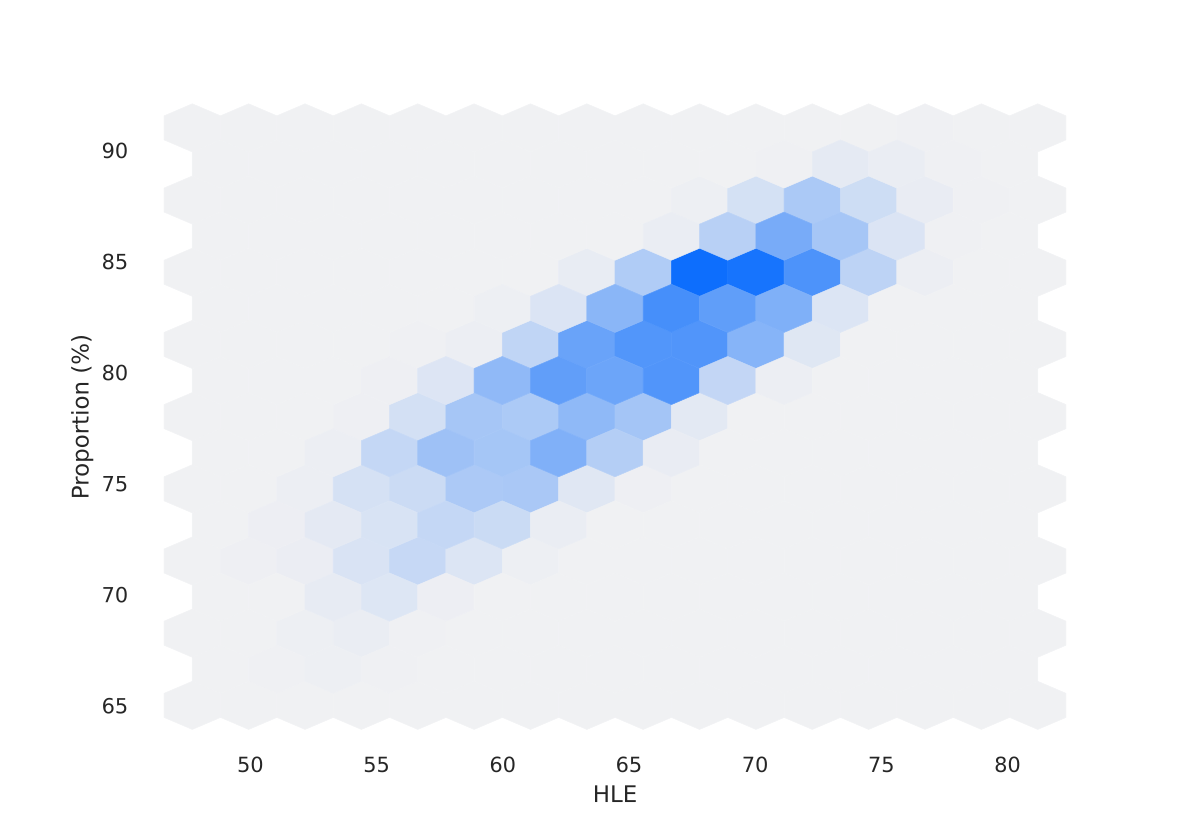

In [3]:
show_hle_profile_chart("hle-distribution.png")
show_hle_profile_chart("healthy-life-proportion.png")
show_hle_profile_chart("hle-and-healthy-life-proportion.png")

**The shape of HLE.** The first chart shows how HLE years are spread out. The next two show the *proportion* of life spent in good health, and how it moves with HLE. They move together because they’re built from the same information, so I’m treating the proportion as a companion to HLE, not a second outcome.

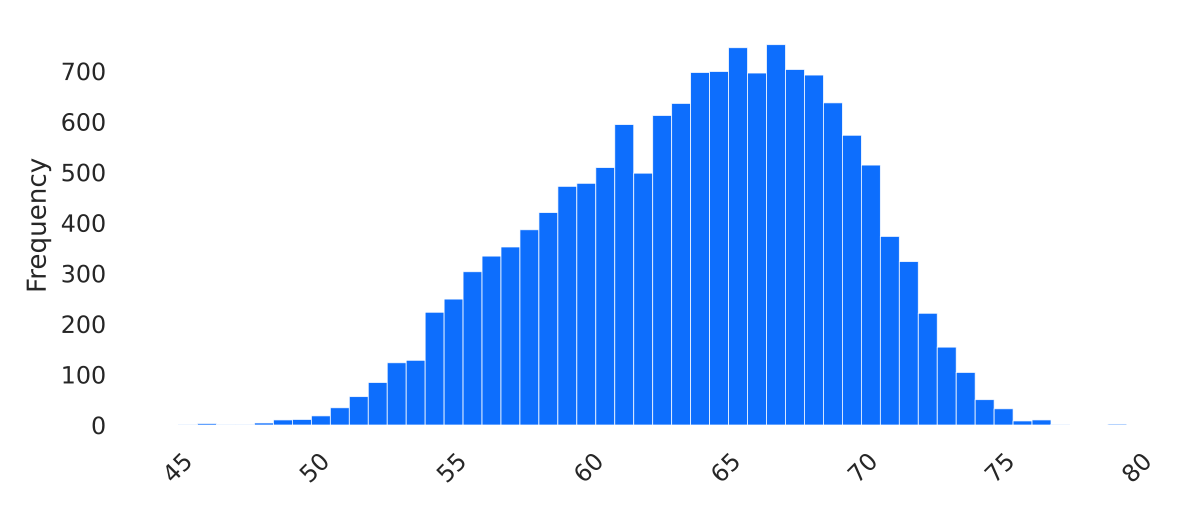

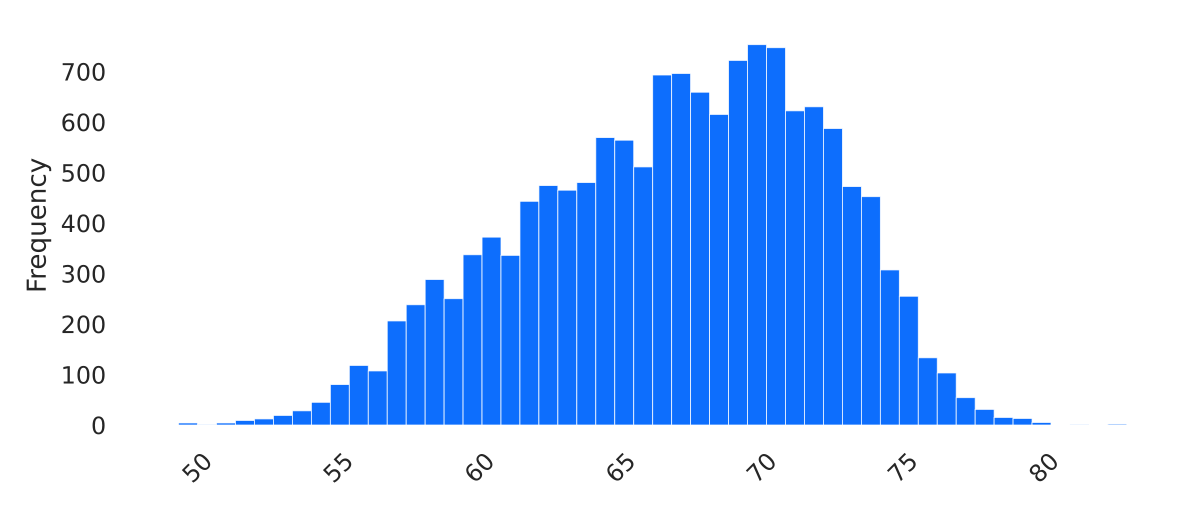

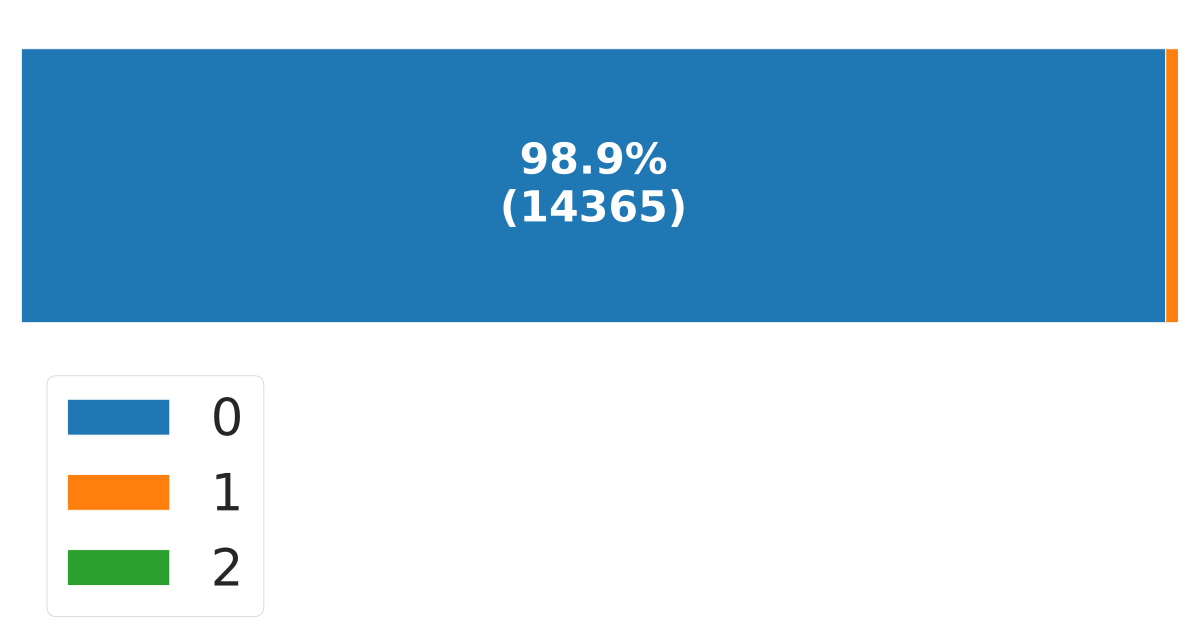

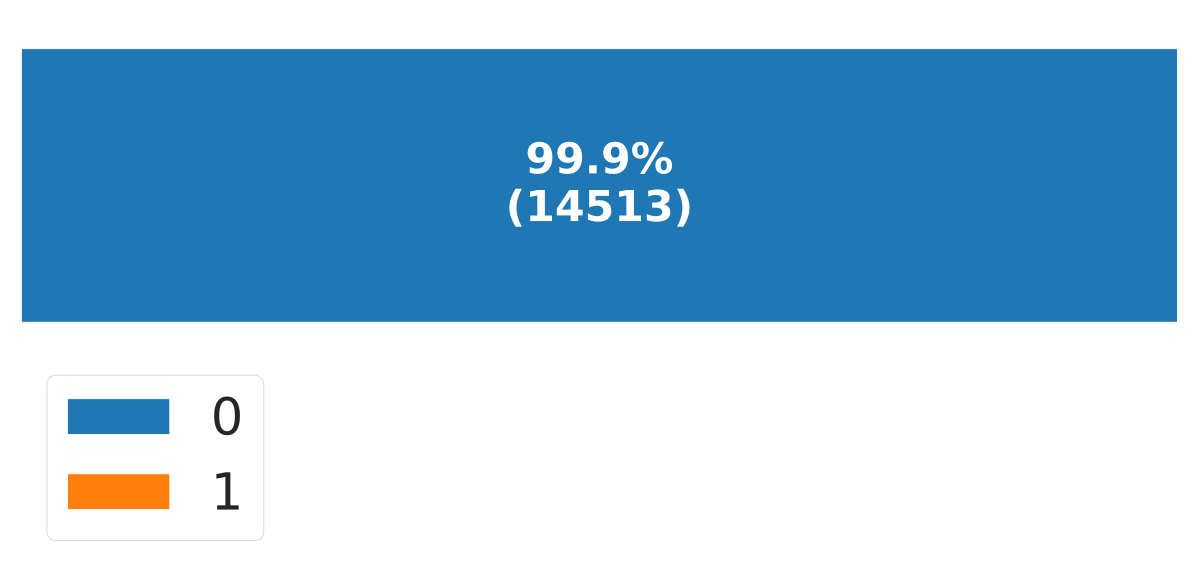

In [4]:
show_hle_profile_chart("lower-confidence-limits.png")
show_hle_profile_chart("upper-confidence-limits.png")
show_hle_profile_chart("life-expectancy-imputation.png")
show_hle_profile_chart("health-prevalence-imputation.png")

**Precision and imputation.** The lower and upper limits are the margin of error around each estimate. They aren’t extra health measures. The imputation charts show that ONS had to fill in some of its inputs for a small number of areas. I look at both properly for my own areas in section 3.

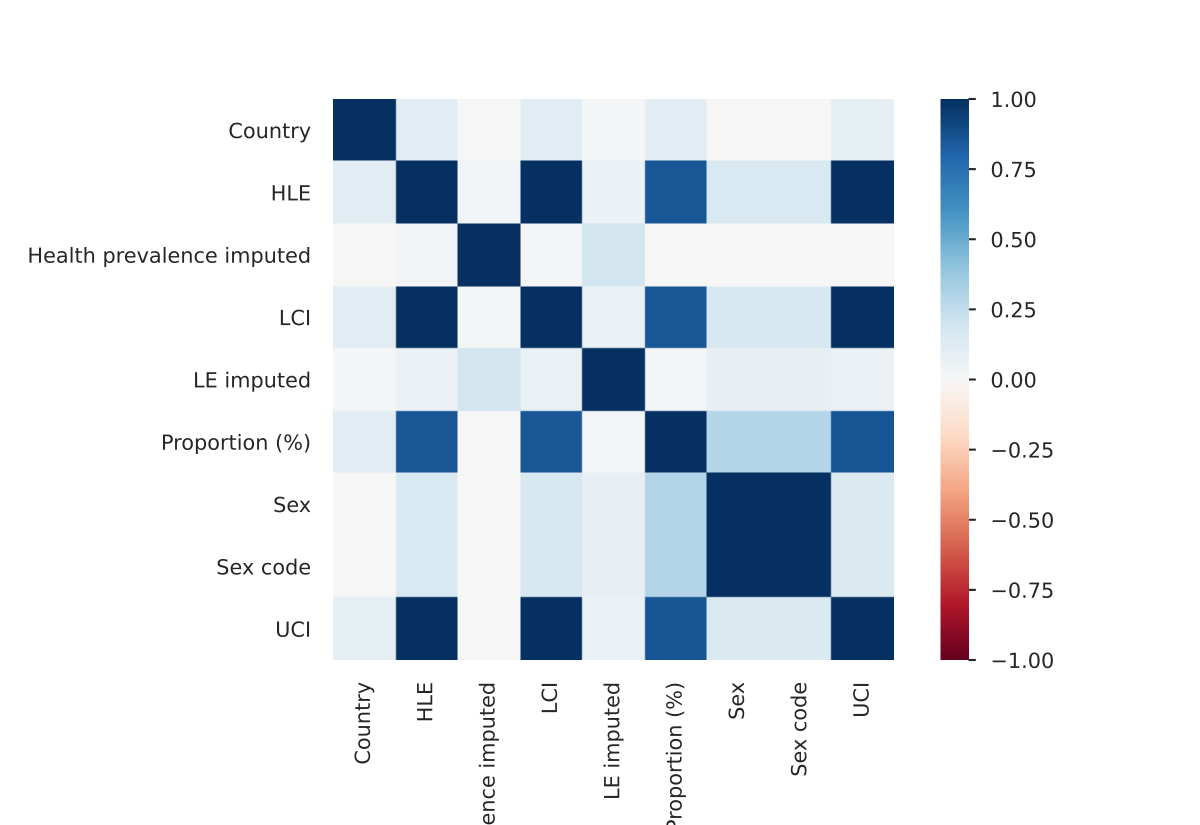

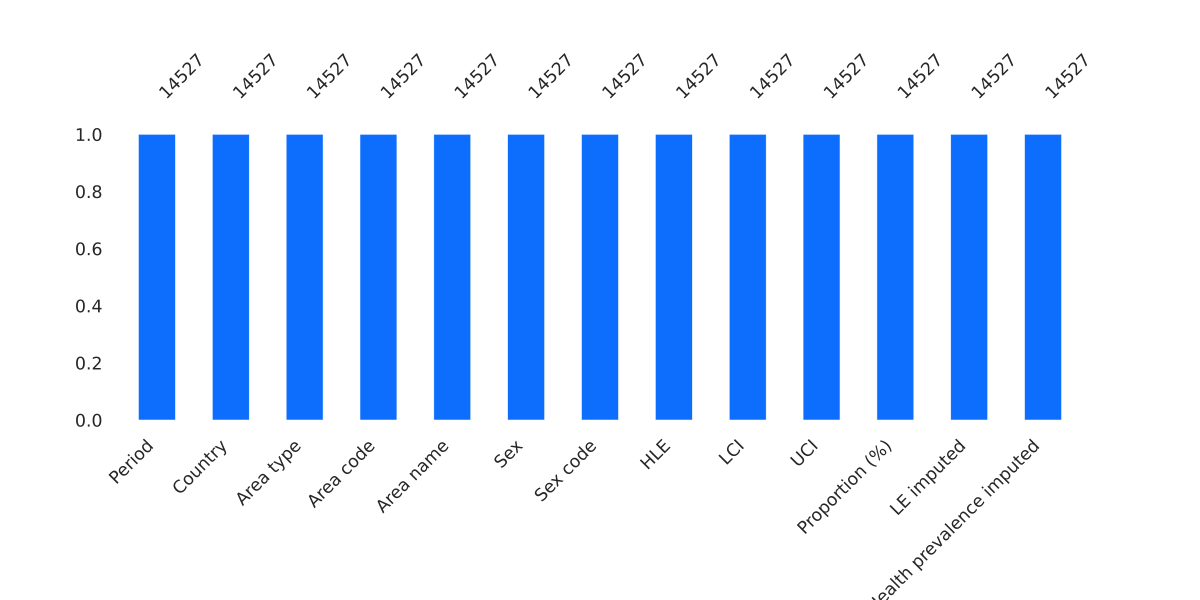

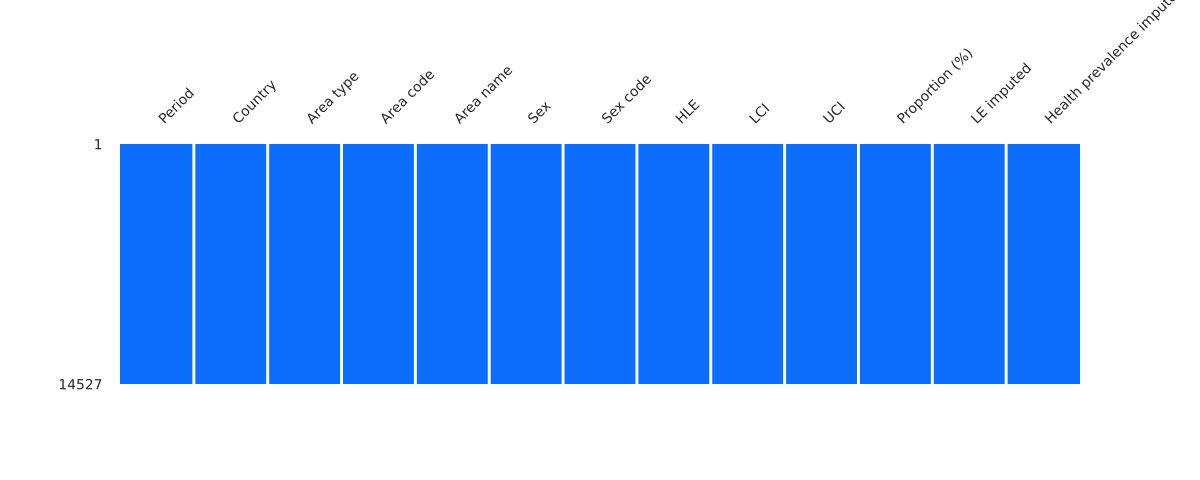

In [5]:
show_hle_profile_chart("source-correlations.png")
show_hle_profile_chart("missing-values-bar.png")
show_hle_profile_chart("missing-values-matrix.png")

**Sanity checks.** HLE and its confidence limits move together, which is obvious, because the limits are built around HLE. The sex code is a label, so I ignore any correlation with it. The missing-value charts are flat: nothing is missing. A complete table can still hold the wrong thing, so next I check what each field means.

## 3. My 660 local areas

From here on I only use my local sample. Each area has one male and one female estimate, so that’s 1,320 rows.

I read sheet `2` of the workbook, which is healthy life expectancy at birth for 2019–2023. Sheet `1` is life expectancy and sheet `3` is disability-free life expectancy, so I need to be careful to pick the right one. I add the familiar local names I use in Notebook 02, so I can say “Sparkbrook North” and not “Birmingham 001”, and I work out each estimate’s margin of error (upper limit minus lower limit).

In [6]:
import json

hle_raw = pd.read_excel(raw_file("ons_hsle_msoa_2019_2023.xlsx"), sheet_name="2", header=6)
hle_msoa = hle_raw.loc[hle_raw["Area code"].astype(str).str.fullmatch(r"[EW]020\d{5}", na=False)].copy()
hle_local = hle_msoa.loc[hle_msoa["Area code"].isin(coverage_codes)].copy()
assert set(hle_local["Area code"]) == coverage_codes

# Familiar local names: the same lookup Notebook 02 uses.
with project_data("Reference/Area Names/locality-names.json").open(encoding="utf-8") as names_file:
    local_names = json.load(names_file)
name_by_code = {
    code: " ".join(part.strip() for part in [entry["display_name"], entry.get("qualifier", "")] if part.strip())
    for code, entry in local_names.items()
}
hle_local["Local name"] = hle_local["Area code"].map(name_by_code)
assert hle_local["Local name"].notna().all()

# Width of the 95% confidence interval: the full margin of error, in years.
hle_local["CI width"] = (hle_local["UCI"] - hle_local["LCI"]).round(1)

display(pd.DataFrame({
    "Source field": hle_msoa.columns,
    "Data type": hle_msoa.dtypes.astype(str).values,
    "Missing cells": hle_msoa.isna().sum().values,
}))
print(f"National MSOA estimates: {len(hle_msoa):,} ({hle_msoa['Sex'].value_counts().to_dict()})")
print(f"Local estimates: {len(hle_local):,} ({hle_local['Sex'].value_counts().to_dict()})")
print("Repeated area/sex/period keys:", hle_local.duplicated(["Area code", "Sex", "Period"]).sum())

,Source field,Data type,Missing cells
0,Period,str,0
1,Country,str,0
2,Area type,str,0
3,Area code,str,0
4,Area name,str,0
5,Sex,str,0
6,Sex code,int64,0
7,HLE,float64,0
8,LCI,float64,0
9,UCI,float64,0


National MSOA estimates: 14,527 ({'Female': 7264, 'Male': 7263})
Local estimates: 1,320 ({'Male': 660, 'Female': 660})
Repeated area/sex/period keys: 0


Nothing is missing, and there are no repeated area-and-sex rows. Nationally there are 7,264 female estimates and 7,263 male ones, so one area somewhere has no male figure. It isn’t one of mine: all 660 of my areas have both.

### How my areas compare with the rest of the country

First question: are my areas any different from the national picture? I compare my 660 areas with the rest of England and Wales. Every area counts once, whatever its population, so these are averages of areas, not of people.

In [7]:
comparison = hle_msoa.assign(
    Group=hle_msoa["Area code"].isin(coverage_codes).map({True: "My 660 areas", False: "Rest of England and Wales"})
).groupby(["Sex", "Group"])["HLE"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
display(comparison)

count   mean  median   std   min   max
Sex    Group                                                            
Female My 660 areas                 660  64.41   64.85  5.31  52.9  76.6
       Rest of England and Wales   6604  66.21   66.80  5.26  49.0  81.2
Male   My 660 areas                 660  63.36   63.50  4.90  52.4  75.4
       Rest of England and Wales   6603  64.86   65.30  5.05  47.7  78.3

My areas sit below the rest of the country. Female HLE averages 64.4 years against 66.2, and male HLE 63.4 against 64.9, so about 1.5 to 1.8 years lower. The spread is just as wide as it is nationally, with a standard deviation of about 5 years in both groups. So I’m not looking at a uniformly lower area. There’s a lot of variation inside it.

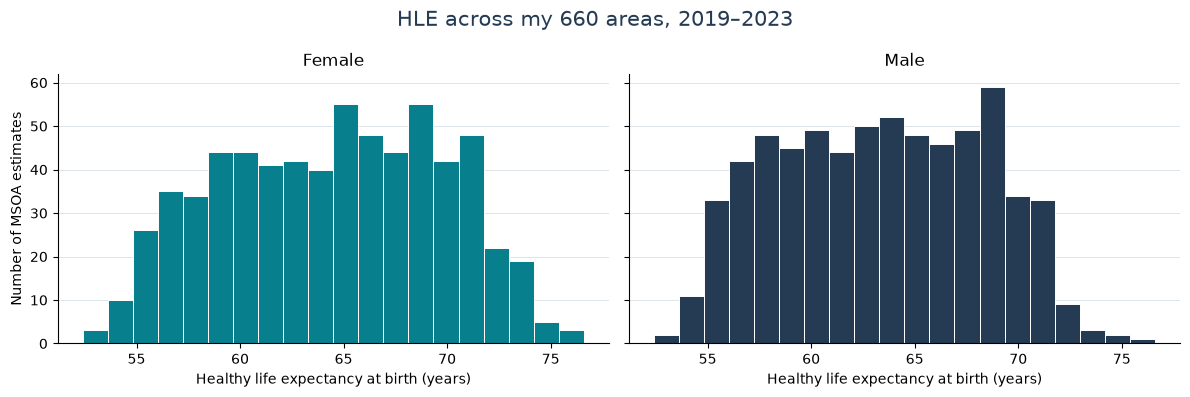

Estimates under 60 years: {'Female': 160, 'Male': 194}


In [8]:
# Same bin boundaries for both sexes so the two distributions are comparable.
import numpy as np
colours = {"Male": "#243b53", "Female": "#087f8c"}
bins = np.linspace(hle_local["HLE"].min(), hle_local["HLE"].max(), 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (sex, table) in zip(axes, hle_local.groupby("Sex"), strict=True):
    ax.hist(table["HLE"].dropna(), bins=bins, color=colours[sex], edgecolor="white", linewidth=0.7)
    ax.set(title=sex, xlabel="Healthy life expectancy at birth (years)")
    ax.set_facecolor("#ffffff")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#d8e0e7", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Number of MSOA estimates")
fig.suptitle("HLE across my 660 areas, 2019–2023", fontsize=15, color="#243b53")
plt.tight_layout()
plt.show()
print("Estimates under 60 years:", hle_local.groupby("Sex")["HLE"].apply(lambda s: int((s < 60).sum())).to_dict())

The range is about 23 years for both sexes: 52.4 to 75.4 for men and 52.9 to 76.6 for women. That’s a big spread. Around 30% of male estimates (194 of 660) and around a quarter of female estimates (160) are under 60 years of healthy life.

### Men and women

I’m keeping the sexes separate, so I want to know how different they are. I take each area’s female figure minus its male figure.

Female higher: 513 | Male higher: 133 | Equal: 14
Correlation between male and female HLE: 0.966


,Female minus male (years)
count,660.00
mean,1.05
std,1.40
min,-4.10
25%,0.10
50%,1.10
75%,1.90
max,7.50


Sex,Local name,Male,Female,Gap
Area code,,,,
E02002815,Normanton North,61.0,56.9,-4.1
E02001908,Sparkhill North,56.7,53.4,-3.3
E02006900,Bordesley,58.2,55.0,-3.2
E02006179,Featherstone West,62.0,68.1,6.1
E02006136,Abbots Bromley,66.6,73.2,6.6
E02006899,Birmingham city centre,59.8,67.3,7.5


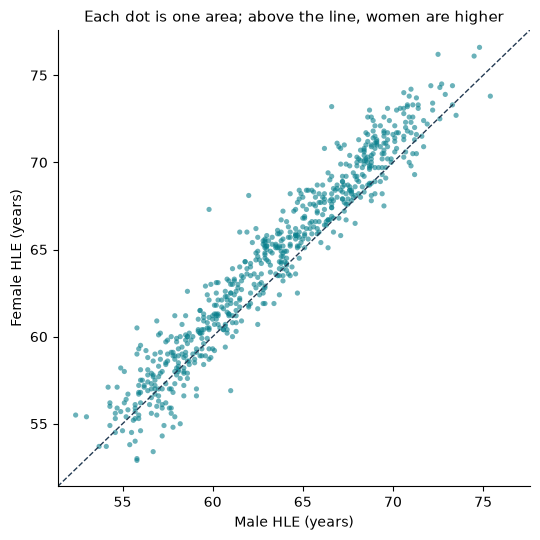

In [9]:
by_sex = hle_local.pivot(index="Area code", columns="Sex", values="HLE")
by_sex["Gap"] = (by_sex["Female"] - by_sex["Male"]).round(1)
by_sex["Local name"] = by_sex.index.map(name_by_code)

print("Female higher:", int((by_sex["Gap"] > 0).sum()),
      "| Male higher:", int((by_sex["Gap"] < 0).sum()),
      "| Equal:", int((by_sex["Gap"] == 0).sum()))
print("Correlation between male and female HLE:", round(by_sex["Male"].corr(by_sex["Female"]), 3))
display(by_sex["Gap"].describe().round(2).to_frame("Female minus male (years)"))
ordered = by_sex.sort_values("Gap")
display(pd.concat([ordered.head(3), ordered.tail(3)])[["Local name", "Male", "Female", "Gap"]])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(by_sex["Male"], by_sex["Female"], s=14, alpha=0.6, color="#087f8c", edgecolor="none")
low, high = by_sex[["Male", "Female"]].min().min() - 1, by_sex[["Male", "Female"]].max().max() + 1
ax.plot([low, high], [low, high], color="#243b53", linewidth=1, linestyle="--")
ax.set(xlim=(low, high), ylim=(low, high), xlabel="Male HLE (years)", ylabel="Female HLE (years)",
       title="Each dot is one area; above the line, women are higher")
ax.title.set_fontsize(11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Women have the higher figure in 513 of the 660 areas, men in 133, and 14 are level. The average gap is about a year in women’s favour, but it runs from 4.1 years in men’s favour (Normanton North) to 7.5 in women’s (Birmingham city centre). Even so, the two sexes track each other closely: the correlation is 0.97. Places with low HLE for men have low HLE for women too, so whatever is driving it seems to hit both. I still keep them separate, because pooling them would hide gaps of that size.

### How precise the estimates are

Each estimate comes with a 95% confidence interval. If the intervals are wide, small differences between areas mean nothing. The chart ranks every area from lowest to highest HLE and draws its interval as a vertical line.

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female,660.0,2.85,0.55,1.8,2.5,2.8,3.1,8.8
Male,660.0,3.04,0.51,2.1,2.7,3.0,3.3,5.8


Spread of HLE across areas (SD) divided by typical margin of error (half-width): {'Female': 3.8, 'Male': 3.3}


,Local name,Sex,HLE,LCI,UCI,CI width
13291,Birmingham city centre,Female,67.3,62.9,71.7,8.8
5549,Wigmore,Female,67.8,63.8,71.8,8.0
3492,Hill Hook,Male,68.4,65.5,71.3,5.8
13290,Birmingham city centre,Male,59.8,57.1,62.5,5.4
12896,Hollywood,Male,68.5,65.9,71.1,5.2


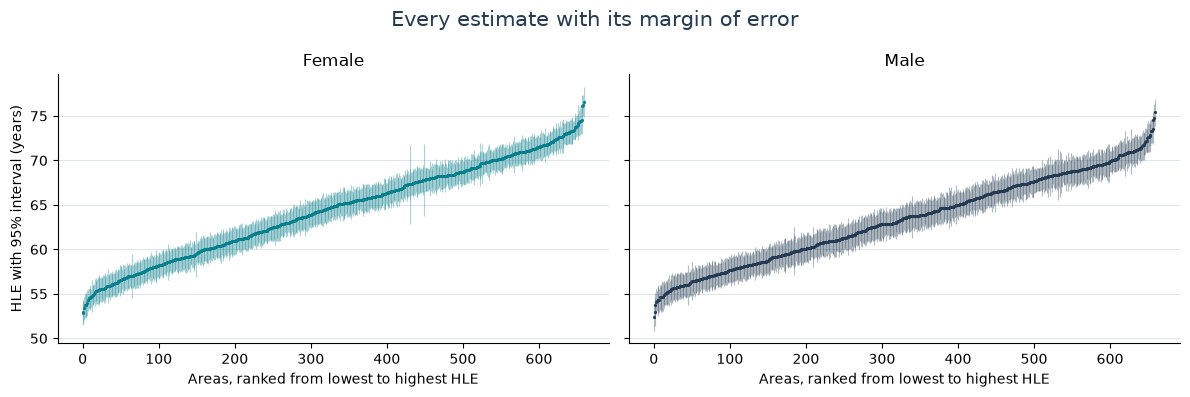

In [10]:
display(hle_local.groupby("Sex")["CI width"].describe().round(2))
half_width = hle_local.groupby("Sex")["CI width"].median() / 2
print("Spread of HLE across areas (SD) divided by typical margin of error (half-width):",
      (hle_local.groupby("Sex")["HLE"].std() / half_width).round(1).to_dict())
display(hle_local.nlargest(5, "CI width")[["Local name", "Sex", "HLE", "LCI", "UCI", "CI width"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (sex, table) in zip(axes, hle_local.groupby("Sex"), strict=True):
    table = table.sort_values("HLE").reset_index(drop=True)
    ax.vlines(table.index, table["LCI"], table["UCI"], color=colours[sex], alpha=0.35, linewidth=0.8)
    ax.plot(table.index, table["HLE"], ".", color=colours[sex], markersize=2.5)
    ax.set(title=sex, xlabel="Areas, ranked from lowest to highest HLE")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#d8e0e7", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("HLE with 95% interval (years)")
fig.suptitle("Every estimate with its margin of error", fontsize=15, color="#243b53")
plt.tight_layout()
plt.show()

A typical interval is about 3 years wide, so roughly 1.5 years either side of the estimate. The spread between areas is three to four times that, so most of the variation I’m looking at is real and not noise. But two areas that are a year apart can’t be told apart, and I shouldn’t rank areas that close together. The widest are the female estimates for Birmingham city centre (67.3 years, interval 62.9 to 71.7) and Wigmore (67.8, interval 63.8 to 71.8). I’ll treat those two with care.

### The imputed estimates

ONS had to fill in some of its inputs for a few areas. The `LE imputed` flag counts how many age groups had population or deaths data imputed. `Health prevalence imputed` says whether any of the Census health data was. I want to see which of my estimates are affected.

In [11]:
flag_fields = ["LE imputed", "Health prevalence imputed"]
flagged = hle_local.loc[(hle_local[flag_fields] > 0).any(axis=1),
                        ["Local name", "Sex", "HLE", "LCI", "UCI", "CI width", *flag_fields]]
display(flagged.sort_values("CI width", ascending=False))
others = hle_local.drop(flagged.index)
print(f"Flagged: {len(flagged)} of {len(hle_local):,} estimates | average interval width: "
      f"{flagged['CI width'].mean():.1f} years, against {others['CI width'].mean():.1f} for the rest")

,Local name,Sex,HLE,LCI,UCI,CI width,LE imputed,Health prevalence imputed
13290,Birmingham city centre,Male,59.8,57.1,62.5,5.4,1,0
13288,Ladywood Summer Hill,Male,62.5,60.5,64.5,4.0,1,0
3976,Smith's Wood North,Male,56.6,55.0,58.3,3.3,1,0
3528,Perry Beeches East,Male,64.6,63.0,66.2,3.2,1,0
3674,Weoley Castle,Male,58.0,56.4,59.6,3.2,1,0
4138,Waterloo Road,Male,57.1,55.5,58.7,3.2,1,0
13282,Attwood Green,Male,58.1,56.6,59.6,3.0,1,0
3914,Princes End,Male,62.1,60.7,63.6,2.9,2,0
5392,Normanton South,Male,57.4,56.1,58.7,2.6,1,0


Flagged: 9 of 1,320 estimates | average interval width: 3.4 years, against 2.9 for the rest


Only 9 of my 1,320 estimates are flagged. All nine are men, and all are for `LE imputed`: one age group each, except Princes End with two. None have imputed health prevalence. Their intervals are a bit wider on average (3.4 years against 2.9). I’m keeping them, and I’ll mark them so I can check later whether my results change without them. ONS also publishes a list of areas with implausible life expectancy figures (sheet `4` of the workbook), and none of my 660 areas are on it.

### Neighbouring areas

This is the question I started with: where do areas next to each other have very different HLE? I find every pair of my areas whose boundaries touch, then take the difference in HLE between the two. Touching includes meeting at a corner, and areas vary a lot in size, so this isn’t the same as “a short walk apart”. It’s a good first look.

In [12]:
boundaries_by_code = boundaries.set_index(boundary_code_field)
area_codes = list(boundaries_by_code.index)
shapes = boundaries_by_code.geometry.values
tree = boundaries_by_code.sindex

touching = set()
for i, shape in enumerate(shapes):
    for j in tree.query(shape, predicate="intersects"):
        if i != j:
            touching.add(tuple(sorted((area_codes[i], area_codes[j]))))
assert not (set(area_codes) - {code for pair in touching for code in pair}), "An area with no neighbour needs a look"

records = []
for first, second in touching:
    for sex in ["Male", "Female"]:
        records.append({
            "Area A": name_by_code[first], "Area B": name_by_code[second], "Sex": sex,
            "HLE A": by_sex.loc[first, sex], "HLE B": by_sex.loc[second, sex],
            "Difference": round(abs(by_sex.loc[first, sex] - by_sex.loc[second, sex]), 1),
        })
neighbours = pd.DataFrame(records)
print(f"Touching pairs: {len(touching):,}")
display(neighbours.groupby("Sex")["Difference"].describe().round(2))
display(neighbours.nlargest(8, "Difference").reset_index(drop=True))

Touching pairs: 1,932


,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female,1932.0,3.79,3.08,0.0,1.4,3.0,5.5,16.4
Male,1932.0,3.62,2.95,0.0,1.3,2.8,5.2,16.3


,Area A,Area B,Sex,HLE A,HLE B,Difference
0,Fox Hollies,Ulverley Green,Female,56.8,73.2,16.4
1,New Oscott,Perry Common College Road,Male,70.6,54.3,16.3
2,Kingstanding North,Perry Common College Road,Female,71.0,54.9,16.1
3,Druids Heath,Wythall,Male,53.0,69.0,16.0
4,Hawkesley,Alvechurch,Female,56.8,72.4,15.6
5,Druids Heath,Hollywood,Female,55.4,71.0,15.6
6,Druids Heath,Hollywood,Male,53.0,68.5,15.5
7,New Oscott,Perry Common College Road,Female,70.3,54.9,15.4


There are 1,932 pairs of touching areas. The typical gap between two neighbours is about 3 years (2.8 for men, 3.0 for women), which is around twice the margin of error. A quarter of pairs differ by more than 5 years. The biggest are huge, at about 16 years: Fox Hollies and Ulverley Green for women (56.8 against 73.2), Druids Heath and Wythall for men (53.0 against 69.0), and New Oscott and Perry Common College Road for men (70.6 against 54.3). Those pairs share a boundary. That’s the pattern I want to map and explain.

## 4. What I’m taking forward

- **Men and women stay separate.** The gap between them reaches 4 years one way and 7.5 the other.
- **HLE in years is the outcome.** The proportion of life in good health is too closely tied to HLE to be a separate measure.
- **Every estimate keeps its interval.** I show the margin of error whenever I compare two areas, and I don’t rank areas that are close together.
- **The nine imputed estimates stay in, but flagged.** I’ll check later whether my results hold without them.
- **No HLE estimates are removed from the data.** None are on ONS’s implausible list. The highest and lowest values look believable and show up for both sexes.
- **A few areas get flagged.** Student-dominated areas and city and town centres with very high crime rates are flagged in Notebook 02. Only the crime figures for the city and town centres are set aside, and every other measure is kept for every area. Birmingham city centre also gets a caveat of its own: it isn't like anywhere else. Their HLE rows stay in the data.